# 03.2.1 — Revisión Pro de 2.000 seguros sospechosos

## Propósito y alcance

Este cuaderno realiza una **tercera revisión independiente y dirigida** de 2.000 chunks que Flash clasificó como seguros, sin `needs_review` y con confianza $\geq 0.90$, pero que el moderador grueso considera cercanos a alguna categoría de daño. No modifica ni ejecuta `03_2_etiquetado_llm_api.ipynb`: usa el mismo prompt compacto, taxonomía, reglas semánticas, contexto vecino y contrato JSON mediante un módulo reanudable separado.

La selección procede exclusivamente de *train + validation*, con máximo tres chunks por video. El cuaderno reproduce la partición agrupada por `video_id` (semilla 131) y exige cero solapamiento de IDs **y videos** con test antes de enviar texto a Pro.

Las etiquetas finas de Pro se guardan solo por trazabilidad y para mejorar criterios de anotación. Para entrenar se proyectan exclusivamente a las cinco categorías gruesas de daño o `SEGURO`; los flags transversales tampoco se convierten en clases base.

## Fundamento metodológico

La estrategia es una forma de revisión dirigida de casos difíciles (*hard-negative mining*): concentra una anotación más costosa en ejemplos que un modelo entrenado ubica cerca de una frontera de daño. Esto puede descubrir falsos negativos útiles para corregir el conjunto de entrenamiento. La literatura sobre aprendizaje activo y depuración de etiquetas respalda priorizar observaciones informativas o potencialmente mal etiquetadas (Brodley & Friedl, 1999; Settles, 2009).

**Límite inferencial:** los 2.000 casos no son una muestra aleatoria del corpus, sino el censo de una selección deliberadamente difícil. Por ello, su tasa de corrección describe ese estrato operativo y sirve para mejorar la frontera de decisión, pero no estima la prevalencia de errores de Flash en los 69 mil chunks (Lohr, 2021). La validación general Flash–Pro y la validación humana probabilística permanecen en `03_2`.

**Referencias (APA 7):**

Brodley, C. E., & Friedl, M. A. (1999). Identifying mislabeled training data. *Journal of Artificial Intelligence Research, 11*, 131–167. https://doi.org/10.1613/jair.606

Lohr, S. L. (2021). *Sampling: Design and analysis* (3rd ed.). Chapman and Hall/CRC.

Settles, B. (2009). *Active learning literature survey* (Computer Sciences Technical Report 1648). University of Wisconsin–Madison. https://research.cs.wisc.edu/techreports/2009/TR1648.pdf

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / 'scripts_auxiliares' / 'revision_sospechosos_pro.py').exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('No se encontró la raíz del proyecto.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts_auxiliares.revision_sospechosos_pro import (
    BATCH_SIZE, MAX_WORKERS, OUTPUT_FILE, OUTPUT_MANIFEST, OUTPUT_METRICS,
    api_preflight, audit_output, load_and_audit_candidates, read_jsonl,
    run_review, write_manifest,
)
from scripts_auxiliares.modelos_gruesos_moderador import (
    COARSE_ORDER, DAMAGE_ORDER, FINE_TO_COARSE,
)

EJECUTAR_PRO = True  # Reanudable: si las 2.000 filas existen, no hace llamadas.
LIMITE = None        # None = completar las 2.000; usa 5 para una prueba de un lote.
print('Raíz:', ROOT)
print('Salida separada:', OUTPUT_FILE)
print({'ejecutar_pro': EJECUTAR_PRO, 'limite': LIMITE, 'batch': BATCH_SIZE, 'workers': MAX_WORKERS})

Raíz: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4
Salida separada: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\datos\etiquetado\llm_api\deepseek-v4-pro_revision_sospechosos_gruesos_seed42.jsonl
{'ejecutar_pro': True, 'limite': None, 'batch': 5, 'workers': 16}


## 1. Preflight sin llamadas facturables

La celda siguiente valida tamaño/unicidad, cobertura canónica, que todos eran Flash-seguros de alta confianza sin `needs_review`, ausencia de Pro previo, y exclusión independiente del test por `chunk_id` y `video_id`. Consultar `/models` no envía textos del corpus.

In [2]:
records, preflight_audit = load_and_audit_candidates()
api_status = api_preflight()
write_manifest(records, preflight_audit)
display(pd.DataFrame([preflight_audit]).T.rename(columns={0: 'valor'}))
print(api_status)
print(f'Llamadas nominales pendientes antes de reintentos: {int(np.ceil(len(records) / BATCH_SIZE)):,}')
print('Manifiesto:', OUTPUT_MANIFEST)

,valor
candidate_rows,2000
unique_ids,2000
videos,905
flash_safe,2000
flash_high_confidence_no_review,2000
overlap_previous_pro,0
overlap_test_ids,0
overlap_test_videos,0
test_rows_reproduced,10293
split_seed,131


{'api_base': 'https://api.deepseek.com', 'model': 'deepseek-v4-pro', 'models_visible': ['deepseek-v4-flash', 'deepseek-v4-pro']}
Llamadas nominales pendientes antes de reintentos: 400
Manifiesto: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\datos\etiquetado\llm_api\deepseek-v4-pro_revision_sospechosos_gruesos_seed42.manifest.json


## 2. Ejecución Pro incremental y reanudable

Cada lote validado se añade inmediatamente al JSONL y se fuerza a disco. Si el kernel o la red se interrumpen, se vuelve a ejecutar esta celda: el proceso valida el prefijo existente y solo envía los IDs pendientes. No se sobrescriben las salidas Flash ni las dos revisiones Pro previas.

In [3]:
if EJECUTAR_PRO:
    run_stats = run_review(records, limit=LIMITE)
    display(pd.DataFrame([run_stats]).T.rename(columns={0: 'valor'}))
else:
    run_stats = audit_output(records)
    print('Ejecución desactivada; solo se auditó cualquier progreso existente.')

,valor
new_rows,0
completed,2000
pending,0
progress_pct,100.0
safe_chunks,1755
damage_chunks,245
needs_review,139
mean_confidence,0.8997
label_counts,"{'seguro': 1649, 'seguro_ironia_marcada': 106,..."
flag_counts,"{'ironia_ambigua': 11, 'humor_encubridor': 93,..."


## 3. Auditoría final y proyección a categorías gruesas

El análisis solo se habilita cuando están presentes y válidas las 2.000 anotaciones. `pro_coarse` se deriva de `labels` mediante el mapeo normativo fino→grueso. Ninguna etiqueta fina ni flag transversal se usa como variable predictora.

In [4]:
final_audit = audit_output(records)
display(pd.DataFrame([final_audit]).T.rename(columns={0: 'valor'}))
if not final_audit['valid'] or final_audit['pending']:
    raise RuntimeError(
        f"La revisión aún no está completa: pendientes={final_audit['pending']}, "
        f"errores={final_audit['errors'][:3]}"
    )

candidates = pd.read_csv(
    ROOT / 'datos' / 'processed' / 'flash_seguros_dificiles_para_revision.csv',
    dtype={'chunk_id': str, 'video_id': str},
)
pro = pd.DataFrame(read_jsonl(OUTPUT_FILE))

def to_coarse(labels):
    mapped = {FINE_TO_COARSE[label] for label in labels}
    return tuple(label for label in COARSE_ORDER if label in mapped)

pro['pro_coarse'] = pro['labels'].map(to_coarse)
pro['pro_damage'] = pro['pro_coarse'].map(lambda values: any(x in DAMAGE_ORDER for x in values))
analysis = candidates.merge(
    pro[['chunk_id', 'pro_coarse', 'pro_damage', 'score_confianza', 'needs_review', 'flags']],
    on='chunk_id', how='inner', validate='one_to_one',
)
assert len(analysis) == 2_000
n_damage = int(analysis['pro_damage'].sum())
n_safe = len(analysis) - n_damage
summary = pd.DataFrame([
    {'resultado_Pro': 'Confirma SEGURO', 'n': n_safe, 'porcentaje': 100*n_safe/len(analysis)},
    {'resultado_Pro': 'Corrige a daño grueso', 'n': n_damage, 'porcentaje': 100*n_damage/len(analysis)},
    {'resultado_Pro': 'Pro aún pide revisión', 'n': int(analysis['needs_review'].sum()),
     'porcentaje': 100*analysis['needs_review'].mean()},
])
display(summary.round(3))

,valor
completed,2000
pending,0
progress_pct,100.0
safe_chunks,1755
damage_chunks,245
needs_review,139
mean_confidence,0.8997
label_counts,"{'seguro': 1649, 'seguro_ironia_marcada': 106,..."
flag_counts,"{'ironia_ambigua': 11, 'humor_encubridor': 93,..."
valid,True


,resultado_Pro,n,porcentaje
0,Confirma SEGURO,1755,87.75
1,Corrige a daño grueso,245,12.25
2,Pro aún pide revisión,139,6.95


## 4. Resultados visuales

El panel izquierdo muestra qué categoría sospechaba el moderador y qué proporción Pro confirmó como daño. El derecho muestra la relación descriptiva entre el score máximo de daño y la confirmación Pro. Como la selección está truncada hacia casos difíciles, estos gráficos no deben extrapolarse al corpus completo.

,categoria_sospechada,n,confirmados_dano,score_medio,tasa_confirmacion
0,RACISMO_DISCRIMINACION,478,45,0.4082,0.0941
1,ACOSO_PERSONAL,930,103,0.4143,0.1108
2,ACOSO_GENERO_IDENTIDAD,305,42,0.4208,0.1377
3,CONTENIDO_SEXUAL,266,48,0.4233,0.1805
4,AMENAZA_DIRECTA,21,7,0.4166,0.3333


,n,score_medio,tasa_confirmacion
0,400,0.3500,0.0225
1,400,0.3696,0.0750
2,400,0.3945,0.0850
3,400,0.4323,0.1275
4,400,0.5289,0.3025


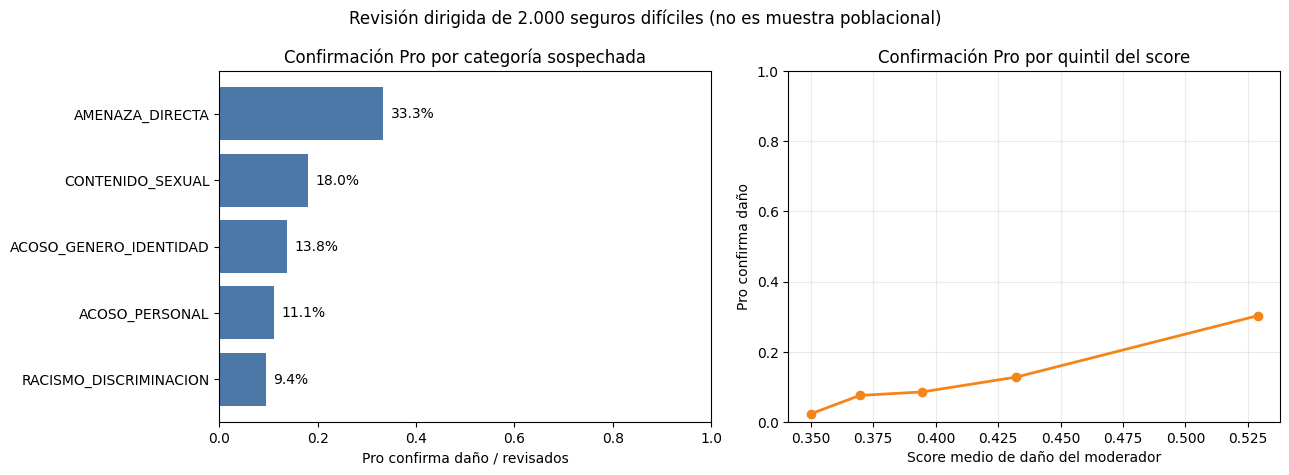

Figura: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\resultados\figuras\revision_pro_sospechosos_2000.png


In [5]:
category_result = (analysis.groupby('categoria_sospechada', observed=True)
                   .agg(n=('chunk_id', 'size'), confirmados_dano=('pro_damage', 'sum'),
                        score_medio=('score_dano_maximo', 'mean'))
                   .assign(tasa_confirmacion=lambda x: x.confirmados_dano / x.n)
                   .sort_values('tasa_confirmacion', ascending=True))
analysis['quintil_score'] = pd.qcut(analysis['score_dano_maximo'], 5, duplicates='drop')
score_result = (analysis.groupby('quintil_score', observed=True)
                .agg(n=('chunk_id', 'size'), score_medio=('score_dano_maximo', 'mean'),
                     tasa_confirmacion=('pro_damage', 'mean'))
                .reset_index(drop=True))
display(category_result.reset_index().round(4))
display(score_result.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].barh(category_result.index, category_result['tasa_confirmacion'], color='#4C78A8')
axes[0].set(xlabel='Pro confirma daño / revisados', ylabel='', xlim=(0, 1),
            title='Confirmación Pro por categoría sospechada')
for y, value in enumerate(category_result['tasa_confirmacion']):
    axes[0].text(min(value + .015, .96), y, f'{value:.1%}', va='center')
axes[1].plot(score_result['score_medio'], score_result['tasa_confirmacion'],
             marker='o', linewidth=2, color='#F58518')
axes[1].set(xlabel='Score medio de daño del moderador', ylabel='Pro confirma daño',
            ylim=(0, 1), title='Confirmación Pro por quintil del score')
axes[1].grid(alpha=.25)
fig.suptitle('Revisión dirigida de 2.000 seguros difíciles (no es muestra poblacional)')
fig.tight_layout()
FIGURE_PATH = ROOT / 'resultados' / 'figuras' / 'revision_pro_sospechosos_2000.png'
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Figura:', FIGURE_PATH)

## 5. ¿Hay que volver a entrenar?

La decisión no se toma a partir de una tasa poblacional —que esta selección no puede estimar— sino de si Pro encontró falsos negativos relevantes para la frontera de entrenamiento. Si existe al menos una corrección a daño, incorporar esas etiquetas requiere volver a ajustar el moderador para que el modelo pueda aprenderlas. La utilidad del cambio se determina comparando el modelo anterior y el reentrenado en validación y, después, una sola vez en el test intacto.

In [6]:
n_damage_pending_review = int((analysis['pro_damage'] & analysis['needs_review']).sum())
n_damage_ready = n_damage - n_damage_pending_review
if n_damage:
    decision = (
        f'**Sí, corresponde reentrenar.** Pro corrigió {n_damage:,} de 2.000 '        f'Flash-seguros ({n_damage/len(analysis):.2%}) a una o más categorías gruesas de daño. '        f'Hay {n_damage_ready:,} correcciones sin duda residual que pueden reemplazar a Flash; '        f'los otros {n_damage_pending_review:,} casos conservan `needs_review=True` y deben ser '        'adjudicados humanamente o excluidos/reducidos de peso antes del ajuste definitivo. '        'Luego se reajustan modelo y umbrales en validación. El test de 10.293 chunks no se toca.'
    )
else:
    decision = (
        '**No es necesario reentrenar por esta revisión.** Pro confirmó los 2.000 casos como '        'seguros; no se introdujeron objetivos gruesos nuevos. Conviene conservar la auditoría '        'como evidencia de que este estrato difícil fue inspeccionado.'
    )
display(Markdown(decision))

decision_payload = {
    'reviewed': len(analysis), 'pro_damage_corrections': n_damage,
    'pro_damage_corrections_without_review_flag': n_damage_ready,
    'pro_damage_corrections_pending_human_review': n_damage_pending_review,
    'correction_rate_selected_stratum': n_damage/len(analysis),
    'retrain_required_to_incorporate_corrections': bool(n_damage),
    'recommended_policy': 'use confident Pro corrections; adjudicate or downweight needs_review cases',
    'test_ids_used_for_selection_or_retraining': 0,
    'training_targets': list(COARSE_ORDER),
    'fine_labels_used_as_features_or_training_targets': False,
}
DECISION_PATH = OUTPUT_FILE.with_suffix('.retraining_decision.json')
DECISION_PATH.write_text(json.dumps(decision_payload, ensure_ascii=False, indent=2), encoding='utf-8')
print('Decisión reproducible:', DECISION_PATH)

**Sí, corresponde reentrenar.** Pro corrigió 245 de 2.000 Flash-seguros (12.25%) a una o más categorías gruesas de daño. Hay 106 correcciones sin duda residual que pueden reemplazar a Flash; los otros 139 casos conservan `needs_review=True` y deben ser adjudicados humanamente o excluidos/reducidos de peso antes del ajuste definitivo. Luego se reajustan modelo y umbrales en validación. El test de 10.293 chunks no se toca.

Decisión reproducible: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\datos\etiquetado\llm_api\deepseek-v4-pro_revision_sospechosos_gruesos_seed42.retraining_decision.json


## 6. Integración posterior

Una revisión completa y válida puede añadirse al flujo híbrido con precedencia `Pro > Flash`. La partición por video y el test deben conservarse. Después se reejecuta el entrenamiento mejorado de `04_1` desde la construcción del dataset/split: ajuste de candidatos en train, selección y umbrales en validation, reajuste final en train+validation, y evaluación comparativa final en el test intacto.

No se debe entrenar una clasificación fina ni usar `flags` como categorías base. Si Pro conserva `needs_review=True`, ese campo sirve para enrutar una revisión posterior, no como etiqueta gruesa adicional.